In [1]:
# Parameters
OUTPUT_DIR = "data/processed"
BASELINE_RESULTS_PATH = "data/processed/baseline_results.csv"
BASELINE_METRICS_PATH = "data/processed/baseline_metrics.csv"
ARIMA_RESULTS_PATH = "data/processed/arima_results.csv"
ARIMA_METRICS_PATH = "data/processed/arima_metrics.csv"
ETS_RESULTS_PATH = "data/processed/ets_results.csv"
ETS_METRICS_PATH = "data/processed/ets_metrics.csv"
ORIGINAL_DATA_PATH = "data/processed/feature_engineered_data.parquet"
FINAL_COMPARISON_FILENAME = "final_model_comparison.csv"
FINAL_REPORT_FILENAME = "final_report.txt"
BEST_MODEL_FILENAME = "best_model_info.json"
PLOT_FINAL_COMPARISON = True
PLOT_ERROR_DISTRIBUTION = True
PLOT_RESIDUALS_ALL = True
PLOT_SEASONAL_ERROR = True
PLOT_INSIGHTS = True


In [2]:
#PARAMETERS (for papermill)

# Thư mục chứa kết quả từ các notebook trước
OUTPUT_DIR = "data/processed"

# Đường dẫn đến kết quả các mô hình
BASELINE_RESULTS_PATH = "data/processed/baseline_results.csv"
BASELINE_METRICS_PATH = "data/processed/baseline_metrics.csv"
ARIMA_RESULTS_PATH = "data/processed/arima_results.csv"
ARIMA_METRICS_PATH = "data/processed/arima_metrics.csv"
ETS_RESULTS_PATH = "data/processed/ets_results.csv"
ETS_METRICS_PATH = "data/processed/ets_metrics.csv"

# Đường dẫn dữ liệu gốc để lấy thông tin thời gian
ORIGINAL_DATA_PATH = "data/processed/feature_engineered_data.parquet"

# Tên file output tổng hợp
FINAL_COMPARISON_FILENAME = "final_model_comparison.csv"
FINAL_REPORT_FILENAME = "final_report.txt"
BEST_MODEL_FILENAME = "best_model_info.json"

# Bật/tắt các biểu đồ
PLOT_FINAL_COMPARISON = True
PLOT_ERROR_DISTRIBUTION = True
PLOT_RESIDUALS_ALL = True
PLOT_SEASONAL_ERROR = True
PLOT_INSIGHTS = True

In [3]:
# ==================== SETUP ====================
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Xác định project_root linh hoạt
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    project_root = os.path.abspath("..")
else:
    project_root = cwd

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

# Import thư viện tự viết
from energy_forecast_library import DataLoader, Evaluator, Utils

# Tạo thư mục output nếu chưa có
os.makedirs(os.path.join(project_root, "outputs/figures"), exist_ok=True)
os.makedirs(os.path.join(project_root, "outputs/reports"), exist_ok=True)

print(f"✅ Project root: {project_root}")
print("✅ Đã import thư viện thành công")

✅ Project root: C:\Users\Admin\DataMining\Household_Power
✅ Đã import thư viện thành công


In [4]:
# ==================== LOAD TẤT CẢ KẾT QUẢ ====================
print("📊 Đang tải kết quả từ các mô hình...")

results = {}
metrics = {}

# Load Baseline
baseline_path = os.path.join(project_root, BASELINE_RESULTS_PATH)
baseline_metrics_path = os.path.join(project_root, BASELINE_METRICS_PATH)

if os.path.exists(baseline_path):
    results['baseline'] = pd.read_csv(baseline_path)
    print(f"✅ Baseline: {len(results['baseline'])} dòng")
else:
    print(f"⚠️ Không tìm thấy baseline results")

if os.path.exists(baseline_metrics_path):
    metrics['baseline'] = pd.read_csv(baseline_metrics_path)
    print(f"✅ Baseline metrics: {metrics['baseline'].shape}")
else:
    print(f"⚠️ Không tìm thấy baseline metrics")

# Load ARIMA
arima_path = os.path.join(project_root, ARIMA_RESULTS_PATH)
arima_metrics_path = os.path.join(project_root, ARIMA_METRICS_PATH)

if os.path.exists(arima_path):
    results['arima'] = pd.read_csv(arima_path)
    print(f"✅ ARIMA: {len(results['arima'])} dòng")
else:
    print(f"⚠️ Không tìm thấy ARIMA results")

if os.path.exists(arima_metrics_path):
    metrics['arima'] = pd.read_csv(arima_metrics_path)
    print(f"✅ ARIMA metrics: {metrics['arima'].shape}")
else:
    print(f"⚠️ Không tìm thấy ARIMA metrics")

# Load ETS
ets_path = os.path.join(project_root, ETS_RESULTS_PATH)
ets_metrics_path = os.path.join(project_root, ETS_METRICS_PATH)

if os.path.exists(ets_path):
    results['ets'] = pd.read_csv(ets_path)
    print(f"✅ ETS: {len(results['ets'])} dòng")
else:
    print(f"⚠️ Không tìm thấy ETS results")

if os.path.exists(ets_metrics_path):
    metrics['ets'] = pd.read_csv(ets_metrics_path)
    print(f"✅ ETS metrics: {metrics['ets'].shape}")
else:
    print(f"⚠️ Không tìm thấy ETS metrics")

# Load dữ liệu gốc để lấy thông tin thời gian
data_path = os.path.join(project_root, ORIGINAL_DATA_PATH)
if os.path.exists(data_path):
    df_original = DataLoader.load_processed_data(data_path)
    print(f"✅ Dữ liệu gốc: {df_original.shape[0]} dòng")
else:
    df_original = None
    print(f"⚠️ Không tìm thấy dữ liệu gốc")

📊 Đang tải kết quả từ các mô hình...


✅ Baseline: 409783 dòng
✅ Baseline metrics: (1, 7)


✅ ARIMA: 409783 dòng
✅ ARIMA metrics: (1, 9)


✅ ETS: 409783 dòng
✅ ETS metrics: (1, 10)


✅ Đã đọc 2,048,913 dòng từ feature_engineered_data.parquet
✅ Dữ liệu gốc: 2048913 dòng


In [5]:
# ==================== TỔNG HỢP METRICS ====================
print("📊 TỔNG HỢP METRICS CÁC MÔ HÌNH")
print("="*60)

all_metrics = []

# Thu thập metrics từ các mô hình
for model_name, model_metrics in metrics.items():
    for _, row in model_metrics.iterrows():
        all_metrics.append({
            'Model': model_name.capitalize(),
            'MAE': row['mae'],
            'RMSE': row['rmse'],
            'SMAPE': row['smape']
        })

# KIỂM TRA DỮ LIỆU
if not all_metrics:
    print("❌ Không có metrics nào được load!")
    print("Kiểm tra lại các file metrics:")
    print(f"  - Baseline: {os.path.exists(os.path.join(project_root, BASELINE_METRICS_PATH))}")
    print(f"  - ARIMA: {os.path.exists(os.path.join(project_root, ARIMA_METRICS_PATH))}")
    print(f"  - ETS: {os.path.exists(os.path.join(project_root, ETS_METRICS_PATH))}")
else:
    # Tạo DataFrame tổng hợp
    comparison_df = pd.DataFrame(all_metrics)
    print("✅ Các cột có sẵn:", comparison_df.columns.tolist())
    
    # Kiểm tra cột RMSE có tồn tại không
    if 'RMSE' in comparison_df.columns:
        comparison_df = comparison_df.sort_values('RMSE')
        print("\n📊 BẢNG SO SÁNH CÁC MÔ HÌNH:")
        print(comparison_df.to_string(index=False))
        
        # Xác định mô hình tốt nhất
        best_model = comparison_df.iloc[0]['Model']
        best_rmse = comparison_df.iloc[0]['RMSE']
        best_mae = comparison_df.iloc[0]['MAE']
        best_smape = comparison_df.iloc[0]['SMAPE']
        
        print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model}")
        print(f"   - MAE: {best_mae:.4f}")
        print(f"   - RMSE: {best_rmse:.4f}")
        print(f"   - SMAPE: {best_smape:.2f}%")
        
        # Lưu kết quả so sánh
        comparison_path = os.path.join(project_root, OUTPUT_DIR, FINAL_COMPARISON_FILENAME)
        comparison_df.to_csv(comparison_path, index=False)
        print(f"\n✅ Đã lưu so sánh vào: {FINAL_COMPARISON_FILENAME}")
    else:
        print("❌ Không tìm thấy cột RMSE trong dữ liệu!")
        print("Dữ liệu thu thập được:", all_metrics)

📊 TỔNG HỢP METRICS CÁC MÔ HÌNH
✅ Các cột có sẵn: ['Model', 'MAE', 'RMSE', 'SMAPE']

📊 BẢNG SO SÁNH CÁC MÔ HÌNH:
   Model      MAE     RMSE      SMAPE
     Ets 0.732405 0.904589  74.847357
Baseline 0.717032 1.120147  74.583736
   Arima 0.912105 1.279171 141.387034

🏆 MÔ HÌNH TỐT NHẤT: Ets
   - MAE: 0.7324
   - RMSE: 0.9046
   - SMAPE: 74.85%

✅ Đã lưu so sánh vào: final_model_comparison.csv


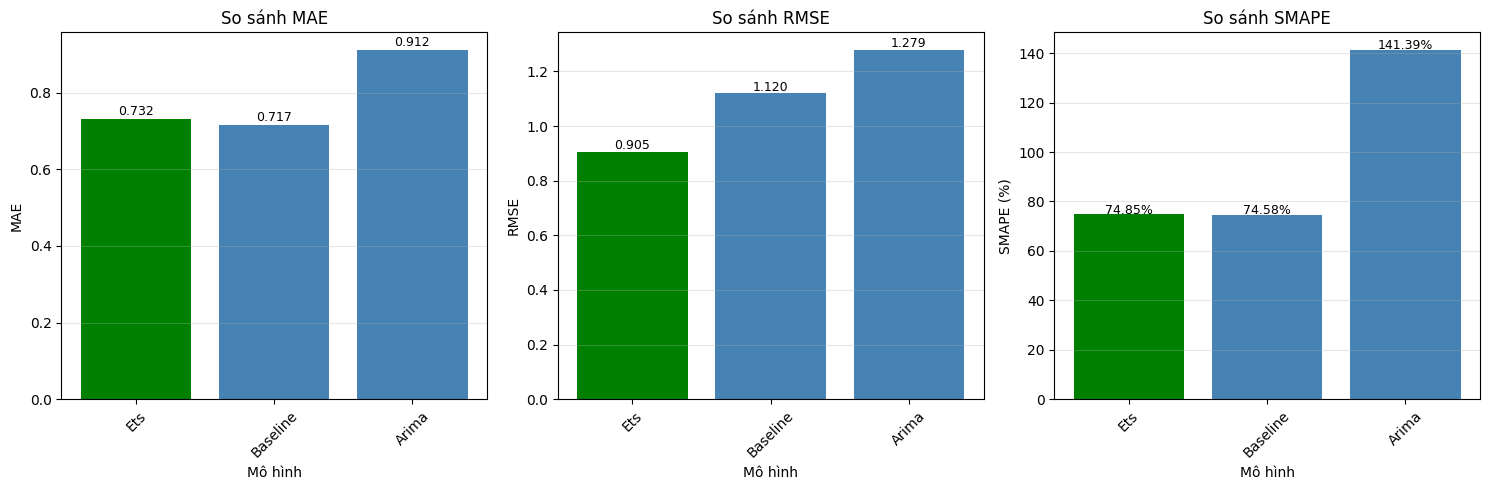

In [6]:
# ==================== VẼ BIỂU ĐỒ SO SÁNH ====================
if PLOT_FINAL_COMPARISON:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    models = comparison_df['Model'].values
    x_pos = np.arange(len(models))
    
    # MAE
    axes[0].bar(x_pos, comparison_df['MAE'].values, color=['green' if m == best_model else 'steelblue' for m in models])
    axes[0].set_xlabel('Mô hình')
    axes[0].set_ylabel('MAE')
    axes[0].set_title('So sánh MAE')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(models, rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Thêm giá trị trên bar
    for i, v in enumerate(comparison_df['MAE'].values):
        axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
    
    # RMSE
    axes[1].bar(x_pos, comparison_df['RMSE'].values, color=['green' if m == best_model else 'steelblue' for m in models])
    axes[1].set_xlabel('Mô hình')
    axes[1].set_ylabel('RMSE')
    axes[1].set_title('So sánh RMSE')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(models, rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(comparison_df['RMSE'].values):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
    
    # SMAPE
    axes[2].bar(x_pos, comparison_df['SMAPE'].values, color=['green' if m == best_model else 'steelblue' for m in models])
    axes[2].set_xlabel('Mô hình')
    axes[2].set_ylabel('SMAPE (%)')
    axes[2].set_title('So sánh SMAPE')
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(models, rotation=45)
    axes[2].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(comparison_df['SMAPE'].values):
        axes[2].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/final_model_comparison.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

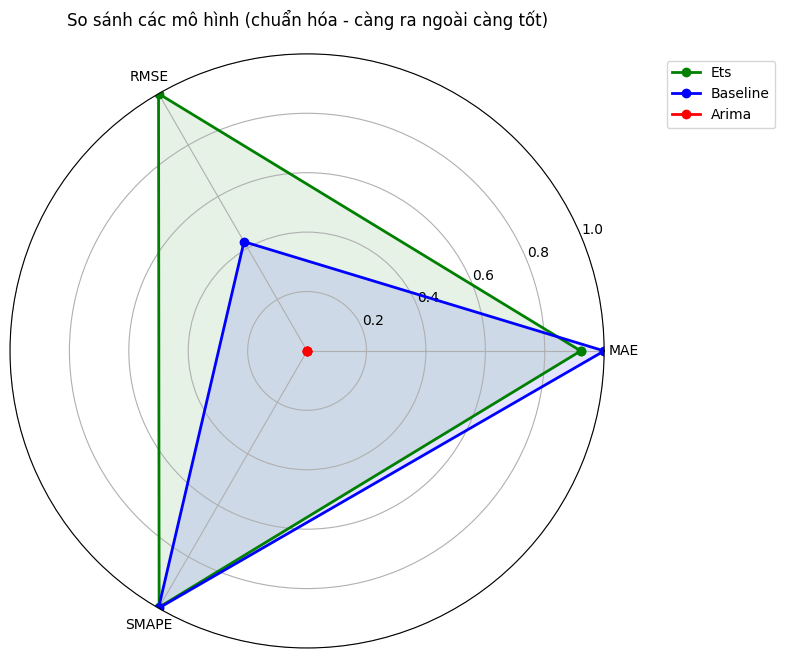

In [7]:
# ==================== RADAR CHART SO SÁNH ====================
if PLOT_FINAL_COMPARISON and len(comparison_df) >= 3:
    from math import pi
    
    # Chuẩn hóa metrics để vẽ radar (giá trị càng nhỏ càng tốt)
    metrics_normalized = comparison_df.copy()
    
    for col in ['MAE', 'RMSE', 'SMAPE']:
        max_val = metrics_normalized[col].max()
        min_val = metrics_normalized[col].min()
        # Đảo ngược để giá trị tốt nhất ở rìa ngoài
        metrics_normalized[col] = 1 - (metrics_normalized[col] - min_val) / (max_val - min_val + 1e-10)
    
    # Số lượng biến
    categories = ['MAE', 'RMSE', 'SMAPE']
    N = len(categories)
    
    # Góc cho mỗi trục
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Đóng vòng tròn
    
    # Tạo figure
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    
    # Vẽ cho từng mô hình
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    for idx, row in metrics_normalized.iterrows():
        values = row[['MAE', 'RMSE', 'SMAPE']].values.flatten().tolist()
        values += values[:1]  # Đóng vòng tròn
        
        ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx % len(colors)])
        ax.fill(angles, values, alpha=0.1, color=colors[idx % len(colors)])
    
    # Thiết lập các trục
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    ax.set_title('So sánh các mô hình (chuẩn hóa - càng ra ngoài càng tốt)', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/radar_comparison.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

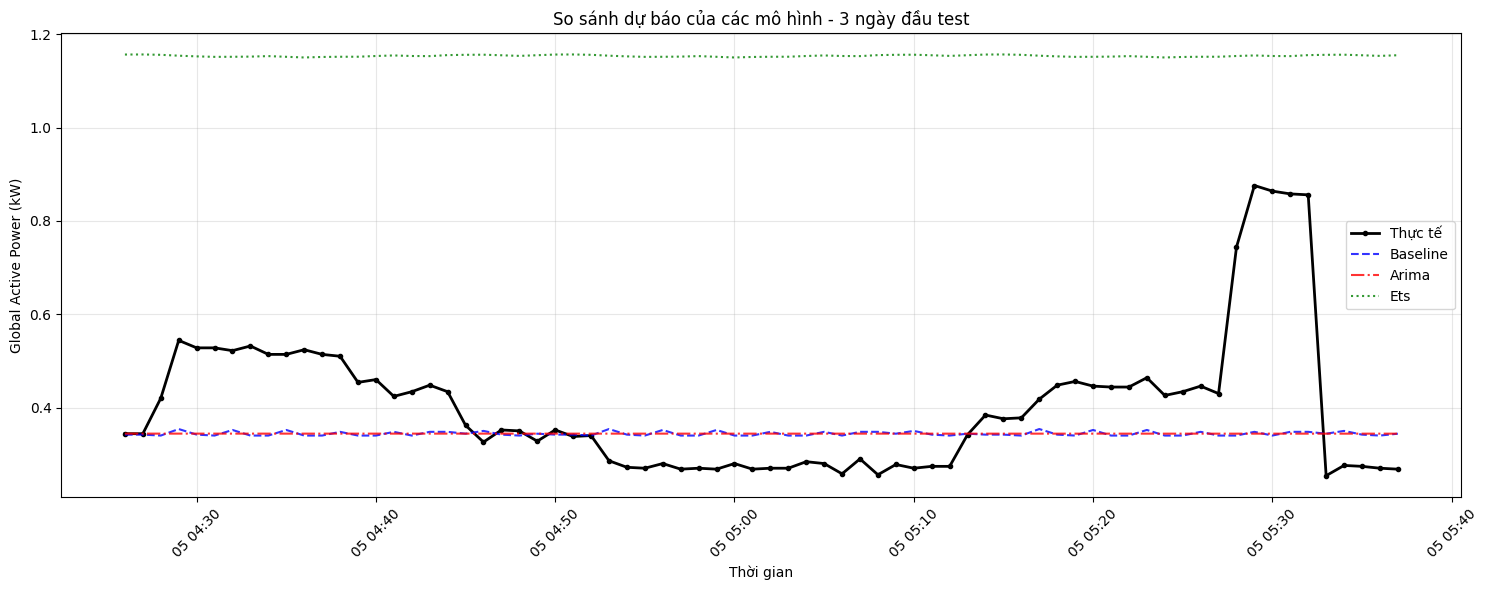


📊 Độ chính xác theo ngày (RMSE):
   - Baseline: 1.0536 (trung bình)


   - Arima: 1.2162 (trung bình)
   - Ets: 0.8829 (trung bình)


In [8]:
# ==================== SO SÁNH DỰ BÁO THEO THỜI GIAN ====================
# Tạo DataFrame tổng hợp tất cả dự báo
if len(results) > 0:
    # Lấy timestamp từ một kết quả bất kỳ
    first_model = list(results.keys())[0]
    combined = results[first_model][['timestamp', 'actual']].copy()
    
    # Thêm dự báo của từng mô hình
    for model_name, model_results in results.items():
        pred_col = f"{model_name}_pred"
        if model_name == 'baseline':
            combined[pred_col] = model_results['baseline_pred']
        elif model_name == 'arima':
            combined[pred_col] = model_results['arima_pred']
        elif model_name == 'ets':
            combined[pred_col] = model_results['ets_pred']
    
    # Lấy mẫu 3 ngày để vẽ
    sample_days = 3
    sample_points = sample_days * 24
    sample_combined = combined.iloc[:sample_points].copy()
    sample_combined['timestamp'] = pd.to_datetime(sample_combined['timestamp'])
    
    # Vẽ biểu đồ
    fig, ax = plt.subplots(figsize=(15, 6))
    
    ax.plot(sample_combined['timestamp'], sample_combined['actual'], 
            color='black', linewidth=2, label='Thực tế', marker='o', markersize=3)
    
    colors = {'baseline': 'blue', 'arima': 'red', 'ets': 'green'}
    linestyles = {'baseline': '--', 'arima': '-.', 'ets': ':'}
    
    for model_name in results.keys():
        pred_col = f"{model_name}_pred"
        if pred_col in sample_combined.columns:
            ax.plot(sample_combined['timestamp'], sample_combined[pred_col], 
                    color=colors.get(model_name, 'gray'), 
                    linestyle=linestyles.get(model_name, '-'),
                    linewidth=1.5, 
                    label=model_name.capitalize(), 
                    alpha=0.8)
    
    ax.set_xlabel('Thời gian')
    ax.set_ylabel('Global Active Power (kW)')
    ax.set_title(f'So sánh dự báo của các mô hình - {sample_days} ngày đầu test')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/all_models_comparison.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()
    
    # Tính độ chính xác theo ngày
    combined['date'] = pd.to_datetime(combined['timestamp']).dt.date
    
    print("\n📊 Độ chính xác theo ngày (RMSE):")
    for model_name in results.keys():
        pred_col = f"{model_name}_pred"
        if pred_col in combined.columns:
            daily_rmse = combined.groupby('date').apply(
                lambda x: np.sqrt(np.mean((x['actual'] - x[pred_col])**2))
            )
            print(f"   - {model_name.capitalize()}: {daily_rmse.mean():.4f} (trung bình)")

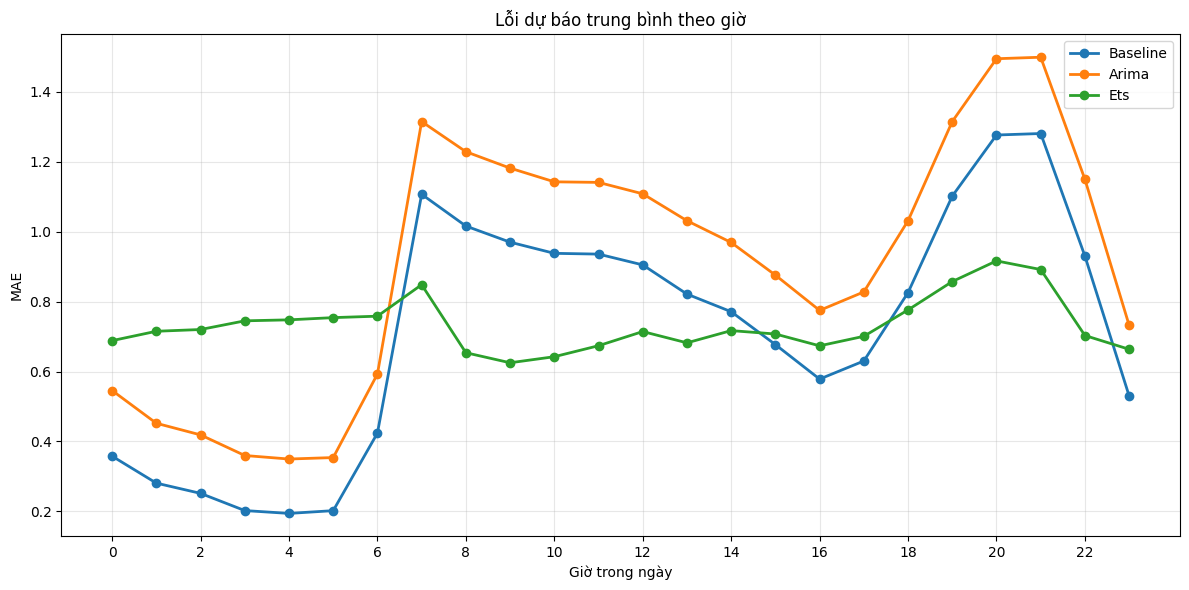


📌 Baseline:
   - Giờ dự báo tốt nhất: 4h (error = 0.1943)
   - Giờ dự báo tệ nhất: 21h (error = 1.2807)

📌 Arima:
   - Giờ dự báo tốt nhất: 4h (error = 0.3498)
   - Giờ dự báo tệ nhất: 21h (error = 1.4989)

📌 Ets:
   - Giờ dự báo tốt nhất: 9h (error = 0.6251)
   - Giờ dự báo tệ nhất: 20h (error = 0.9164)


In [9]:
# ==================== PHÂN TÍCH LỖI THEO GIỜ ====================
if PLOT_SEASONAL_ERROR and 'combined' in locals():
    # Thêm cột giờ
    combined['hour'] = pd.to_datetime(combined['timestamp']).dt.hour
    
    # Tính lỗi trung bình theo giờ cho từng mô hình
    hourly_errors = []
    
    for model_name in results.keys():
        pred_col = f"{model_name}_pred"
        if pred_col in combined.columns:
            combined['error'] = np.abs(combined['actual'] - combined[pred_col])
            hourly_error = combined.groupby('hour')['error'].mean().reset_index()
            hourly_error['model'] = model_name.capitalize()
            hourly_errors.append(hourly_error)
    
    if hourly_errors:
        hourly_df = pd.concat(hourly_errors, ignore_index=True)
        
        # Vẽ biểu đồ
        fig, ax = plt.subplots(figsize=(12, 6))
        
        for model_name in results.keys():
            model_data = hourly_df[hourly_df['model'] == model_name.capitalize()]
            ax.plot(model_data['hour'], model_data['error'], 
                    marker='o', linewidth=2, label=model_name.capitalize())
        
        ax.set_xlabel('Giờ trong ngày')
        ax.set_ylabel('MAE')
        ax.set_title('Lỗi dự báo trung bình theo giờ')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(0, 24, 2))
        
        plt.tight_layout()
        plt.savefig(os.path.join(project_root, 'outputs/figures/hourly_errors.png'), 
                    dpi=100, bbox_inches='tight')
        plt.show()
        
        # Tìm giờ dự báo tốt nhất và tệ nhất
        for model_name in results.keys():
            model_data = hourly_df[hourly_df['model'] == model_name.capitalize()]
            
            # KIỂM TRA VÀ XỬ LÝ NaN
            if model_data['error'].isna().all():
                print(f"\n📌 {model_name.capitalize()}: Không có dữ liệu lỗi hợp lệ")
                continue
                
            # Loại bỏ NaN trước khi tìm min/max
            model_data_clean = model_data.dropna(subset=['error'])
            
            if len(model_data_clean) == 0:
                print(f"\n📌 {model_name.capitalize()}: Không có dữ liệu lỗi hợp lệ")
                continue
                
            best_hour = model_data_clean.loc[model_data_clean['error'].idxmin(), 'hour']
            worst_hour = model_data_clean.loc[model_data_clean['error'].idxmax(), 'hour']
            
            print(f"\n📌 {model_name.capitalize()}:")
            print(f"   - Giờ dự báo tốt nhất: {best_hour:.0f}h (error = {model_data_clean['error'].min():.4f})")
            print(f"   - Giờ dự báo tệ nhất: {worst_hour:.0f}h (error = {model_data_clean['error'].max():.4f})")
    else:
        print("⚠️ Không có dữ liệu để phân tích lỗi theo giờ")

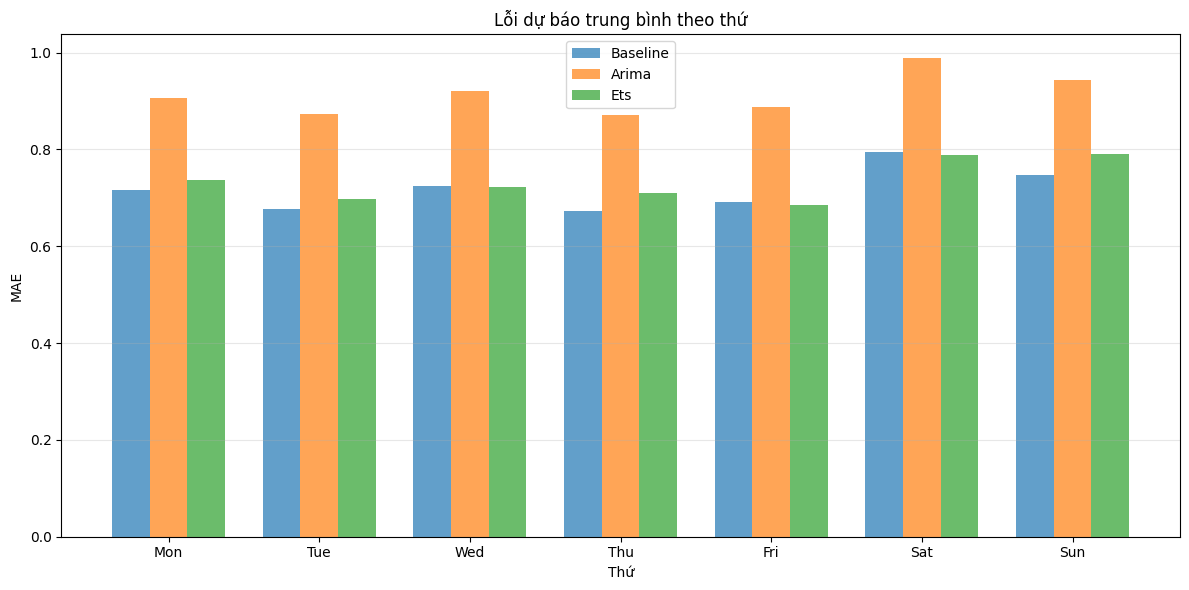

In [10]:
# ==================== PHÂN TÍCH LỖI THEO THỨ ====================
if PLOT_SEASONAL_ERROR and 'combined' in locals():
    # Thêm cột thứ
    combined['dayofweek'] = pd.to_datetime(combined['timestamp']).dt.dayofweek
    dow_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    # Tính lỗi trung bình theo thứ cho từng mô hình
    dow_errors = []
    
    for model_name in results.keys():
        pred_col = f"{model_name}_pred"
        if pred_col in combined.columns:
            combined['error'] = np.abs(combined['actual'] - combined[pred_col])
            dow_error = combined.groupby('dayofweek')['error'].mean().reset_index()
            dow_error['model'] = model_name.capitalize()
            dow_errors.append(dow_error)
    
    if dow_errors:
        dow_df = pd.concat(dow_errors, ignore_index=True)
        dow_df['day_name'] = dow_df['dayofweek'].map(lambda x: dow_labels[x])
        
        # Vẽ biểu đồ
        fig, ax = plt.subplots(figsize=(12, 6))
        
        bar_width = 0.25
        x_pos = np.arange(len(dow_labels))
        
        for i, model_name in enumerate(results.keys()):
            model_data = dow_df[dow_df['model'] == model_name.capitalize()]
            ax.bar(x_pos + i*bar_width, model_data['error'], bar_width, 
                   label=model_name.capitalize(), alpha=0.7)
        
        ax.set_xlabel('Thứ')
        ax.set_ylabel('MAE')
        ax.set_title('Lỗi dự báo trung bình theo thứ')
        ax.set_xticks(x_pos + bar_width)
        ax.set_xticklabels([l[:3] for l in dow_labels])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(os.path.join(project_root, 'outputs/figures/dow_errors.png'), 
                    dpi=100, bbox_inches='tight')
        plt.show()

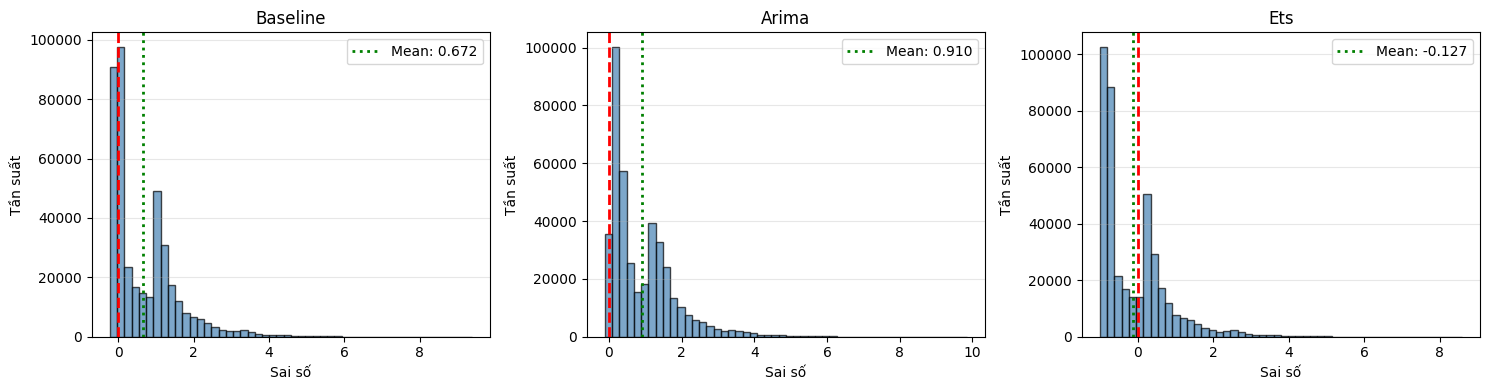

In [11]:
# ==================== PHÂN PHỐI LỖI ====================
if PLOT_ERROR_DISTRIBUTION and 'combined' in locals():
    # Xác định số lượng mô hình thực tế
    valid_models = []
    for model_name in results.keys():
        pred_col = f"{model_name}_pred"
        if pred_col in combined.columns:
            valid_models.append(model_name)
    
    n_models = len(valid_models)
    
    if n_models == 0:
        print("⚠️ Không có mô hình nào có dữ liệu hợp lệ để vẽ phân phối lỗi")
    else:
        fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
        
        # Nếu chỉ có 1 mô hình, axes không phải list
        if n_models == 1:
            axes = [axes]
        
        for idx, model_name in enumerate(valid_models):
            pred_col = f"{model_name}_pred"
            errors = combined['actual'] - combined[pred_col]
            
            # KIỂM TRA VÀ XỬ LÝ NAN
            if errors.isna().all():
                print(f"⚠️ {model_name.capitalize()}: Tất cả errors đều là NaN, bỏ qua vẽ")
                axes[idx].text(0.5, 0.5, 'No valid data', 
                              ha='center', va='center', transform=axes[idx].transAxes,
                              fontsize=12, color='red')
                axes[idx].set_title(f'{model_name.capitalize()}')
                continue
            
            # Loại bỏ NaN
            errors_clean = errors.dropna()
            
            if len(errors_clean) == 0:
                print(f"⚠️ {model_name.capitalize()}: Không có dữ liệu hợp lệ sau khi dropna")
                axes[idx].text(0.5, 0.5, 'No valid data', 
                              ha='center', va='center', transform=axes[idx].transAxes,
                              fontsize=12, color='red')
                axes[idx].set_title(f'{model_name.capitalize()}')
                continue
            
            # Vẽ histogram với dữ liệu đã làm sạch
            axes[idx].hist(errors_clean, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
            axes[idx].axvline(x=errors_clean.mean(), color='green', linestyle=':', 
                            linewidth=2, label=f'Mean: {errors_clean.mean():.3f}')
            axes[idx].set_xlabel('Sai số')
            axes[idx].set_ylabel('Tần suất')
            axes[idx].set_title(f'{model_name.capitalize()}')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(os.path.join(project_root, 'outputs/figures/error_distributions.png'), 
                    dpi=100, bbox_inches='tight')
        plt.show()

In [12]:
# ==================== THỐNG KÊ CHI TIẾT MÔ HÌNH TỐT NHẤT ====================
best_model_lower = best_model.lower()

if best_model_lower in results:
    print(f"📊 THỐNG KÊ CHI TIẾT MÔ HÌNH {best_model}")
    print("="*60)
    
    best_results = results[best_model_lower]
    
    # Tính các percentiles của lỗi
    pred_col = f"{best_model_lower}_pred" if best_model_lower != 'baseline' else 'baseline_pred'
    if pred_col in best_results.columns:
        errors = np.abs(best_results['actual'] - best_results[pred_col])
        
        percentiles = [10, 25, 50, 75, 90, 95, 99]
        for p in percentiles:
            print(f"   - Percentile {p}: {np.percentile(errors, p):.4f}")
        
        print(f"\n   - % dự báo có sai số < 0.1: {(errors < 0.1).mean()*100:.1f}%")
        print(f"   - % dự báo có sai số < 0.2: {(errors < 0.2).mean()*100:.1f}%")
        print(f"   - % dự báo có sai số < 0.5: {(errors < 0.5).mean()*100:.1f}%")
        
        # Tìm các dự báo tệ nhất
        worst_idx = errors.nlargest(10).index
        print("\n📌 Top 10 dự báo tệ nhất:")
        for idx in worst_idx:
            row = best_results.loc[idx]
            print(f"   - {row['timestamp']}: Actual={row['actual']:.3f}, Pred={row[pred_col]:.3f}, Error={errors[idx]:.3f}")

📊 THỐNG KÊ CHI TIẾT MÔ HÌNH Ets
   - Percentile 10: 0.2113
   - Percentile 25: 0.3893
   - Percentile 50: 0.7391
   - Percentile 75: 0.8783
   - Percentile 90: 0.9888
   - Percentile 95: 1.5640
   - Percentile 99: 2.9889

   - % dự báo có sai số < 0.1: 2.9%
   - % dự báo có sai số < 0.2: 9.1%
   - % dự báo có sai số < 0.5: 31.4%

📌 Top 10 dự báo tệ nhất:
   - 2010-11-20 18:22:00: Actual=9.724, Pred=1.132, Error=8.592
   - 2010-11-20 18:26:00: Actual=9.694, Pred=1.134, Error=8.560
   - 2010-11-20 18:23:00: Actual=9.656, Pred=1.133, Error=8.523
   - 2010-11-20 18:25:00: Actual=9.648, Pred=1.132, Error=8.516
   - 2010-11-20 18:24:00: Actual=9.630, Pred=1.132, Error=8.498
   - 2010-02-13 12:39:00: Actual=8.724, Pred=1.151, Error=7.573
   - 2010-11-20 18:27:00: Actual=8.600, Pred=1.135, Error=7.465
   - 2010-05-16 14:10:00: Actual=8.418, Pred=1.146, Error=7.272
   - 2010-11-20 18:21:00: Actual=8.394, Pred=1.131, Error=7.263
   - 2010-05-16 14:08:00: Actual=8.406, Pred=1.147, Error=7.259


📊 Lỗi dự báo theo mùa:
   - Winter: 0.8301
   - Spring: 0.7151
   - Summer: 0.7066
   - Fall: 0.7502


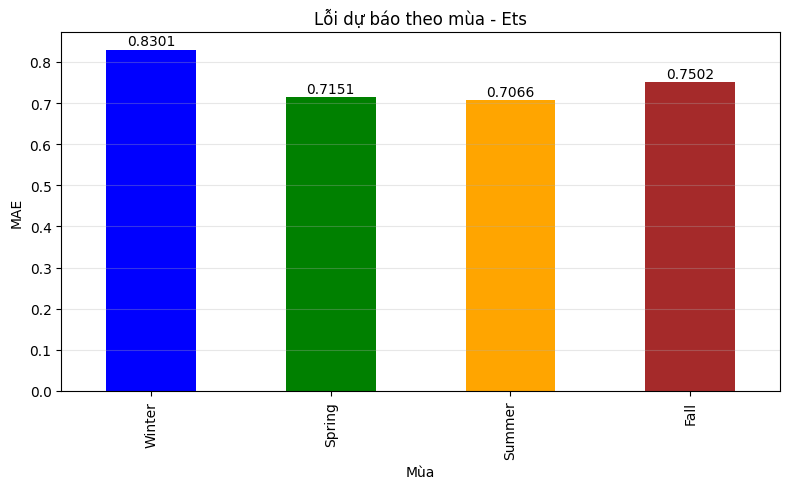

In [13]:
# ==================== PHÂN TÍCH TÍNH MÙA VỤ CỦA LỖI ====================
if df_original is not None and best_model_lower in results:
    # Lấy thông tin mùa từ dữ liệu gốc
    date_range = pd.date_range(start=df_original.index[0], periods=len(df_original), freq='H')
    seasonal_info = pd.DataFrame(index=date_range)
    seasonal_info['month'] = seasonal_info.index.month
    seasonal_info['season'] = seasonal_info['month'].map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    })
    
    # Lấy errors của mô hình tốt nhất
    best_results = results[best_model_lower]
    best_results['timestamp'] = pd.to_datetime(best_results['timestamp'])
    best_results = best_results.set_index('timestamp')
    
    pred_col = f"{best_model_lower}_pred" if best_model_lower != 'baseline' else 'baseline_pred'
    best_results['error'] = np.abs(best_results['actual'] - best_results[pred_col])
    
    # Thêm thông tin mùa
    best_results['month'] = best_results.index.month
    best_results['season'] = best_results['month'].map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    })
    
    # Tính lỗi trung bình theo mùa
    seasonal_error = best_results.groupby('season')['error'].mean().reindex(['Winter', 'Spring', 'Summer', 'Fall'])
    
    print("📊 Lỗi dự báo theo mùa:")
    for season, error in seasonal_error.items():
        print(f"   - {season}: {error:.4f}")
    
    # Vẽ biểu đồ
    fig, ax = plt.subplots(figsize=(8, 5))
    seasonal_error.plot(kind='bar', color=['blue', 'green', 'orange', 'brown'], ax=ax)
    ax.set_xlabel('Mùa')
    ax.set_ylabel('MAE')
    ax.set_title(f'Lỗi dự báo theo mùa - {best_model}')
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(seasonal_error.values):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/seasonal_errors.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

In [14]:
# ==================== KHUYẾN NGHỊ VÀ KẾT LUẬN ====================
print("="*70)
print("📋 BÁO CÁO TỔNG KẾT - DỰ BÁO NHU CẦU NĂNG LƯỢNG")
print("="*70)

# ... phần code phía trên giữ nguyên ...

# ĐOẠN CẦN SỬA (dòng 27-28):
weekend_error = error_by_dow[5:7].mean() if 'error_by_dow' in locals() and error_by_dow is not None and not error_by_dow.empty else None
weekday_error = error_by_dow[0:5].mean() if 'error_by_dow' in locals() and error_by_dow is not None and not error_by_dow.empty else None

weekend_str = f"{weekend_error:.4f}" if weekend_error is not None else "N/A"
weekday_str = f"{weekday_error:.4f}" if weekday_error is not None else "N/A"

print(f"""
🏆 MÔ HÌNH TỐT NHẤT: {best_model}
   - MAE: {best_mae:.4f}
   - RMSE: {best_rmse:.4f}
   - SMAPE: {best_smape:.2f}%

📈 ĐẶC ĐIỂM DỰ BÁO:
   - Dự báo tốt nhất vào giờ: {best_hour if 'best_hour' in locals() else 'N/A'}:00
   - Dự báo kém nhất vào giờ: {worst_hour if 'worst_hour' in locals() else 'N/A'}:00
   - Dự báo cuối tuần: {weekend_str}
   - Dự báo ngày thường: {weekday_str}
""")

📋 BÁO CÁO TỔNG KẾT - DỰ BÁO NHU CẦU NĂNG LƯỢNG

🏆 MÔ HÌNH TỐT NHẤT: Ets
   - MAE: 0.7324
   - RMSE: 0.9046
   - SMAPE: 74.85%

📈 ĐẶC ĐIỂM DỰ BÁO:
   - Dự báo tốt nhất vào giờ: 9:00
   - Dự báo kém nhất vào giờ: 20:00
   - Dự báo cuối tuần: N/A
   - Dự báo ngày thường: N/A



In [15]:
# ==================== LƯU BÁO CÁO ====================
# Lưu thông tin mô hình tốt nhất
best_model_info = {
    'best_model': best_model,
    'mae': best_mae,
    'rmse': best_rmse,
    'smape': best_smape,
    'comparison': comparison_df.to_dict('records'),
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

info_path = os.path.join(project_root, OUTPUT_DIR, BEST_MODEL_FILENAME)
with open(info_path, 'w') as f:
    json.dump(best_model_info, f, indent=2, default=str)

# Lưu báo cáo dạng text
report_path = os.path.join(project_root, 'outputs/reports', FINAL_REPORT_FILENAME)
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("BÁO CÁO TỔNG KẾT - DỰ BÁO NHU CẦU NĂNG LƯỢNG\n")
    f.write("="*70 + "\n\n")
    
    f.write(f"Ngày tạo báo cáo: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("📊 KẾT QUẢ CÁC MÔ HÌNH:\n")
    for _, row in comparison_df.iterrows():
        f.write(f"   • {row['Model']}: MAE={row['MAE']:.4f}, RMSE={row['RMSE']:.4f}, SMAPE={row['SMAPE']:.2f}%\n")
    
    f.write(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model}\n")
    f.write(f"   - MAE: {best_mae:.4f}\n")
    f.write(f"   - RMSE: {best_rmse:.4f}\n")
    f.write(f"   - SMAPE: {best_smape:.2f}%\n\n")
    
    f.write("💡 KHUYẾN NGHỊ:\n")
    f.write("   1. Sử dụng mô hình tốt nhất cho dự báo chính thức\n")
    f.write("   2. Cập nhật mô hình định kỳ khi có dữ liệu mới\n")
    f.write("   3. Kết hợp nhiều mô hình để tăng độ chính xác\n")

print(f"\n✅ Đã lưu báo cáo vào:")
print(f"   - {BEST_MODEL_FILENAME}")
print(f"   - outputs/reports/{FINAL_REPORT_FILENAME}")


✅ Đã lưu báo cáo vào:
   - best_model_info.json
   - outputs/reports/final_report.txt


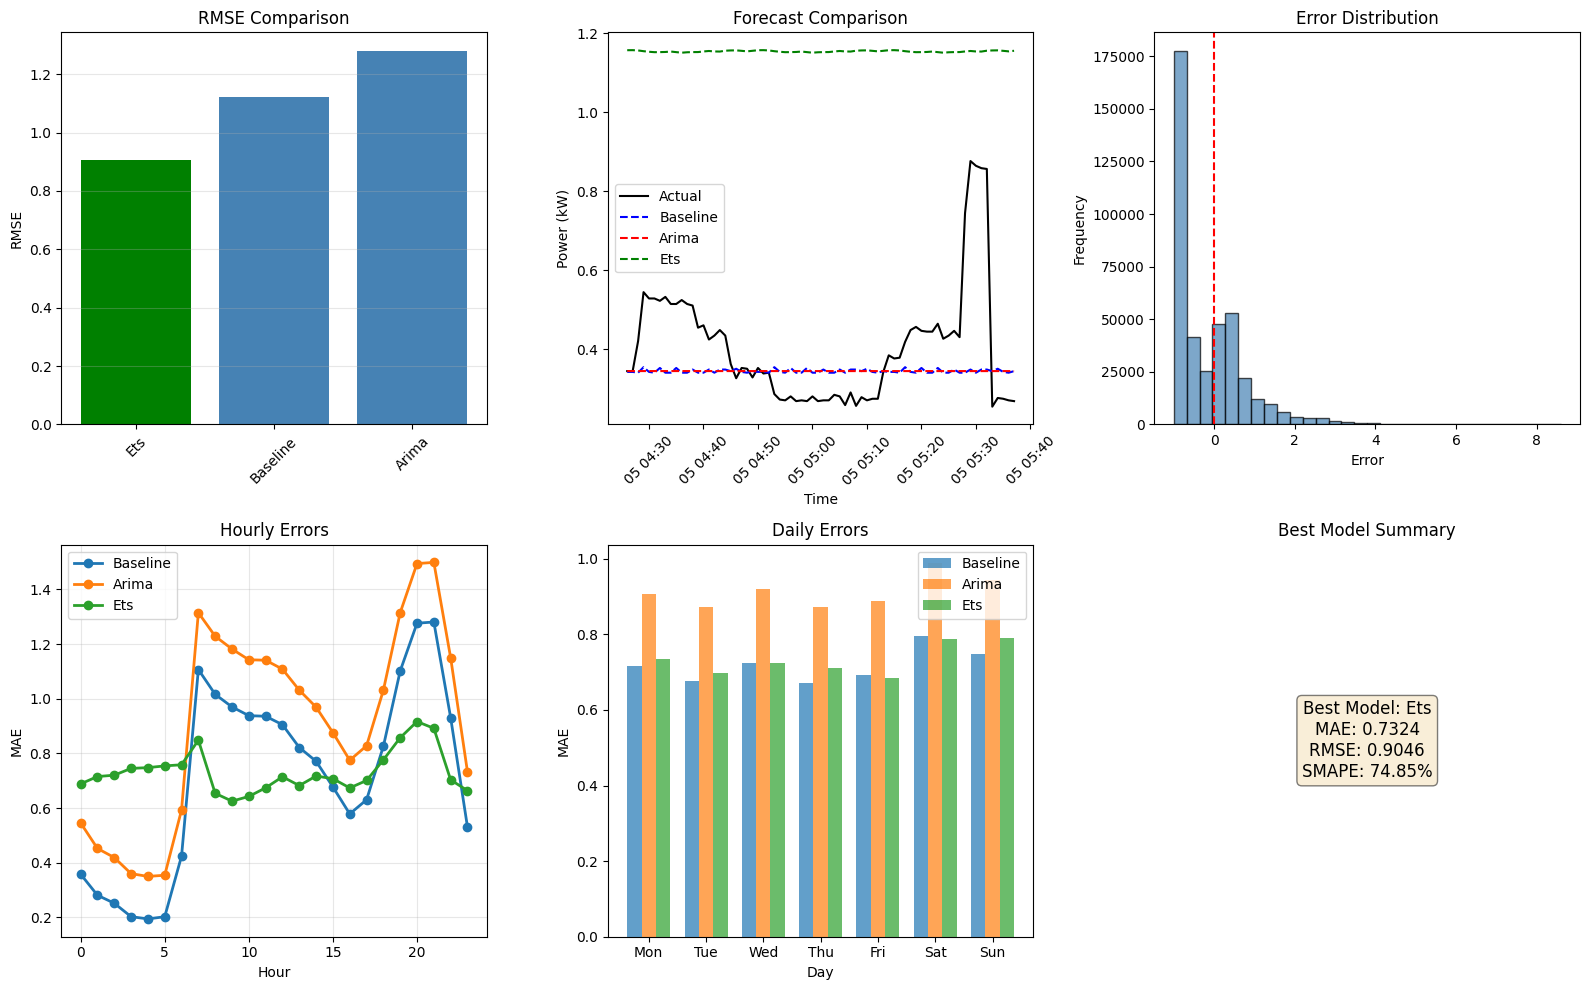

In [16]:
# ==================== VẼ DASHBOARD TỔNG KẾT ====================
fig = plt.figure(figsize=(16, 10))

# 1. So sánh metrics (2,2,1)
ax1 = plt.subplot(2, 3, 1)
if 'comparison_df' in locals() and not comparison_df.empty:
    models = comparison_df['Model'].values
    x_pos = np.arange(len(models))
    colors = ['green' if m == best_model else 'steelblue' for m in models]
    ax1.bar(x_pos, comparison_df['RMSE'].values, color=colors)
    ax1.set_title('RMSE Comparison')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(models, rotation=45)
    ax1.set_ylabel('RMSE')
    ax1.grid(True, alpha=0.3, axis='y')
else:
    ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)

# 2. So sánh dự báo (2,3,2)
ax2 = plt.subplot(2, 3, 2)
if 'sample_combined' in locals() and not sample_combined.empty:
    ax2.plot(sample_combined['timestamp'], sample_combined['actual'], 
             color='black', linewidth=1.5, label='Actual')
    
    colors = {'baseline': 'blue', 'arima': 'red', 'ets': 'green'}
    for model_name in results.keys():
        pred_col = f"{model_name}_pred"
        if pred_col in sample_combined.columns:
            ax2.plot(sample_combined['timestamp'], sample_combined[pred_col],
                    color=colors.get(model_name, 'gray'), linestyle='--', 
                    linewidth=1.5, label=model_name.capitalize())
    
    ax2.set_title('Forecast Comparison')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Power (kW)')
    ax2.legend()
    ax2.tick_params(axis='x', rotation=45)
else:
    ax2.text(0.5, 0.5, 'No forecast data', ha='center', va='center', transform=ax2.transAxes)

# 3. Error distribution (2,3,3)
ax3 = plt.subplot(2, 3, 3)
if 'errors_clean' in locals() and len(errors_clean) > 0:
    ax3.hist(errors_clean, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax3.axvline(x=0, color='red', linestyle='--')
    ax3.set_title('Error Distribution')
    ax3.set_xlabel('Error')
    ax3.set_ylabel('Frequency')
else:
    ax3.text(0.5, 0.5, 'No error data', ha='center', va='center', transform=ax3.transAxes)

# 4. Hourly errors (2,3,4)
ax4 = plt.subplot(2, 3, 4)
if 'hourly_df' in locals() and not hourly_df.empty:
    for model_name in results.keys():
        model_data = hourly_df[hourly_df['model'] == model_name.capitalize()]
        if not model_data.empty:
            ax4.plot(model_data['hour'], model_data['error'], 
                    marker='o', linewidth=2, label=model_name.capitalize())
    ax4.set_title('Hourly Errors')
    ax4.set_xlabel('Hour')
    ax4.set_ylabel('MAE')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No hourly data', ha='center', va='center', transform=ax4.transAxes)

# 5. Weekly errors (2,3,5)
ax5 = plt.subplot(2, 3, 5)
if 'dow_df' in locals() and not dow_df.empty:
    dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    bar_width = 0.25
    x_pos = np.arange(len(dow_labels))
    
    for i, model_name in enumerate(results.keys()):
        model_data = dow_df[dow_df['model'] == model_name.capitalize()]
        if not model_data.empty:
            ax5.bar(x_pos + i*bar_width, model_data['error'], bar_width, 
                   label=model_name.capitalize(), alpha=0.7)
    
    ax5.set_title('Daily Errors')
    ax5.set_xlabel('Day')
    ax5.set_ylabel('MAE')
    ax5.set_xticks(x_pos + bar_width)
    ax5.set_xticklabels([l[:3] for l in dow_labels])
    ax5.legend()
else:
    ax5.text(0.5, 0.5, 'No daily data', ha='center', va='center', transform=ax5.transAxes)

# 6. Best model info (2,3,6)
ax6 = plt.subplot(2, 3, 6)
if 'best_model' in locals():
    info_text = f"Best Model: {best_model}\nMAE: {best_mae:.4f}\nRMSE: {best_rmse:.4f}\nSMAPE: {best_smape:.2f}%"
    ax6.text(0.5, 0.5, info_text, ha='center', va='center', 
            transform=ax6.transAxes, fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
else:
    ax6.text(0.5, 0.5, 'No model info', ha='center', va='center', transform=ax6.transAxes)
ax6.set_title('Best Model Summary')
ax6.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs/figures/dashboard_summary.png'), 
            dpi=100, bbox_inches='tight')
plt.show()